In [2]:
import pandas as pd
from prophet import Prophet

In [3]:
df = pd.read_csv('dataset.csv')
df.head(5)

,Time Date,Product,Store,Value
0,1012018,2667437,QLD_CW_ST0203,2926.000
1,2012018,2667437,QLD_CW_ST0203,2687.531
2,3012018,2667437,QLD_CW_ST0203,2793.000
3,4012018,2667437,QLD_CW_ST0203,2394.000
4,5012018,2667437,QLD_CW_ST0203,2660.000


In [6]:
df['Year'] = df['Time Date'].apply(lambda x: str(x)[-4:])
df['Month'] = df['Time Date'].apply(lambda x: str(x)[-6:-4])
df['day'] = df['Time Date'].apply(lambda x: str(x)[:-6])
df['ds'] = pd.DatetimeIndex(df['Year']+'-'+df['Month']+'-'+df['day'])

In [7]:
df.head(5)

,Time Date,Product,Store,Value,Year,Month,day,ds
0,1012018,2667437,QLD_CW_ST0203,2926.000,2018,01,1,2018-01-01
1,2012018,2667437,QLD_CW_ST0203,2687.531,2018,01,2,2018-01-02
2,3012018,2667437,QLD_CW_ST0203,2793.000,2018,01,3,2018-01-03
3,4012018,2667437,QLD_CW_ST0203,2394.000,2018,01,4,2018-01-04
4,5012018,2667437,QLD_CW_ST0203,2660.000,2018,01,5,2018-01-05


In [8]:
df = df.loc[(df['Product']==2667437)&(df['Store']=='QLD_CW_ST0203')]

In [ ]:
df

,Time Date,Product,Store,Value,Year,Month,day,ds
0,1012018,2667437,QLD_CW_ST0203,2926.000000,2018,01,1,2018-01-01
1,2012018,2667437,QLD_CW_ST0203,2687.531000,2018,01,2,2018-01-02
2,3012018,2667437,QLD_CW_ST0203,2793.000000,2018,01,3,2018-01-03
3,4012018,2667437,QLD_CW_ST0203,2394.000000,2018,01,4,2018-01-04
4,5012018,2667437,QLD_CW_ST0203,2660.000000,2018,01,5,2018-01-05
...,...,...,...,...,...,...,...,...
1075,12122020,2667437,QLD_CW_ST0203,3167.594500,2020,12,12,2020-12-12
1076,13122020,2667437,QLD_CW_ST0203,3167.594500,2020,12,13,2020-12-13
1077,14122020,2667437,QLD_CW_ST0203,3383.354511,2020,12,14,2020-12-14
1078,15122020,2667437,QLD_CW_ST0203,2714.591329,2020,12,15,2020-12-15


In [10]:
df['Product'].unique()

array([2667437], dtype=int64)

In [11]:
df['Store'].unique()

array(['QLD_CW_ST0203'], dtype=object)

In [12]:
df.columns

Index(['Time Date', 'Product', 'Store', 'Value', 'Year', 'Month', 'day', 'ds'], dtype='object')

In [14]:
df.drop(['Time Date', 'Product', 'Store', 'Year', 'Month', 'day'],axis=1, inplace=True)

In [15]:
df.columns

Index(['Value', 'ds'], dtype='object')

In [16]:
df.columns = ['y','ds']

In [17]:
df.head(5)

,y,ds
0,2926.000,2018-01-01
1,2687.531,2018-01-02
2,2793.000,2018-01-03
3,2394.000,2018-01-04
4,2660.000,2018-01-05


In [18]:
m = Prophet(interval_width=0.95, daily_seasonality=True)
model = m.fit(df)

10:24:54 - cmdstanpy - INFO - Chain [1] start processing
10:24:55 - cmdstanpy - INFO - Chain [1] done processing


In [19]:
future = m.make_future_dataframe(periods=100, freq='D')
forecast = m.predict(future)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2018-01-01,3042.251898,852.645473,4069.296599,3042.251898,3042.251898,-639.626465,-639.626465,-639.626465,470.727508,470.727508,470.727508,16.629058,16.629058,16.629058,-1126.983030,-1126.983030,-1126.983030,0.0,0.0,0.0,2402.625434
1,2018-01-02,3042.980205,808.089248,3905.236581,3042.980205,3042.980205,-649.811202,-649.811202,-649.811202,470.727508,470.727508,470.727508,-11.277410,-11.277410,-11.277410,-1109.261299,-1109.261299,-1109.261299,0.0,0.0,0.0,2393.169003
2,2018-01-03,3043.708512,844.410060,4076.290273,3043.708512,3043.708512,-624.033994,-624.033994,-624.033994,470.727508,470.727508,470.727508,-4.409680,-4.409680,-4.409680,-1090.351821,-1090.351821,-1090.351821,0.0,0.0,0.0,2419.674518
3,2018-01-04,3044.436819,769.615031,4050.191702,3044.436819,3044.436819,-577.105920,-577.105920,-577.105920,470.727508,470.727508,470.727508,22.496805,22.496805,22.496805,-1070.330233,-1070.330233,-1070.330233,0.0,0.0,0.0,2467.330899
4,2018-01-05,3045.165126,911.253822,4068.262190,3045.165126,3045.165126,-613.165218,-613.165218,-613.165218,470.727508,470.727508,470.727508,-34.567751,-34.567751,-34.567751,-1049.324974,-1049.324974,-1049.324974,0.0,0.0,0.0,2431.999907


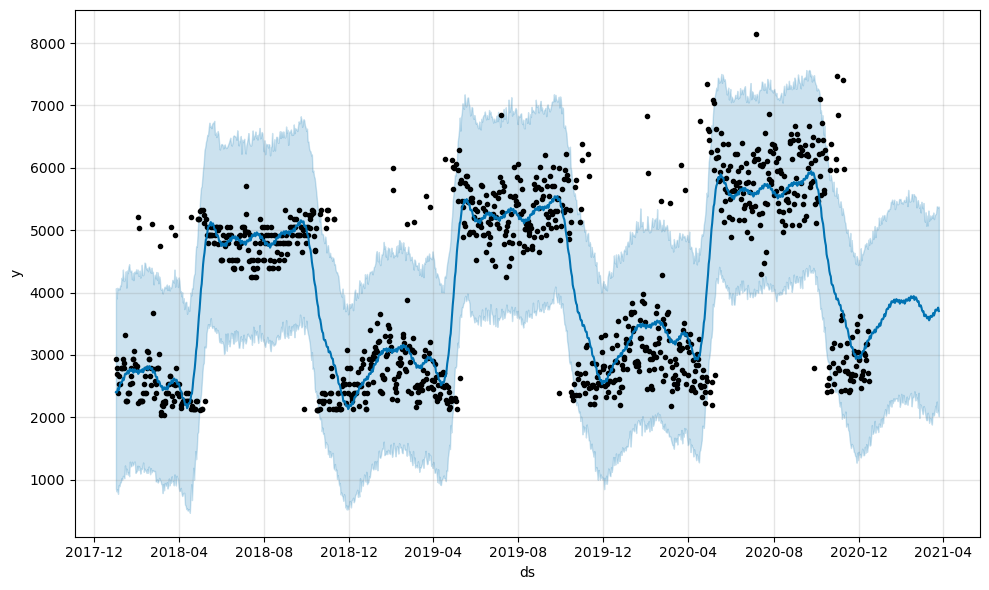

In [20]:
plot1 = m.plot(forecast)

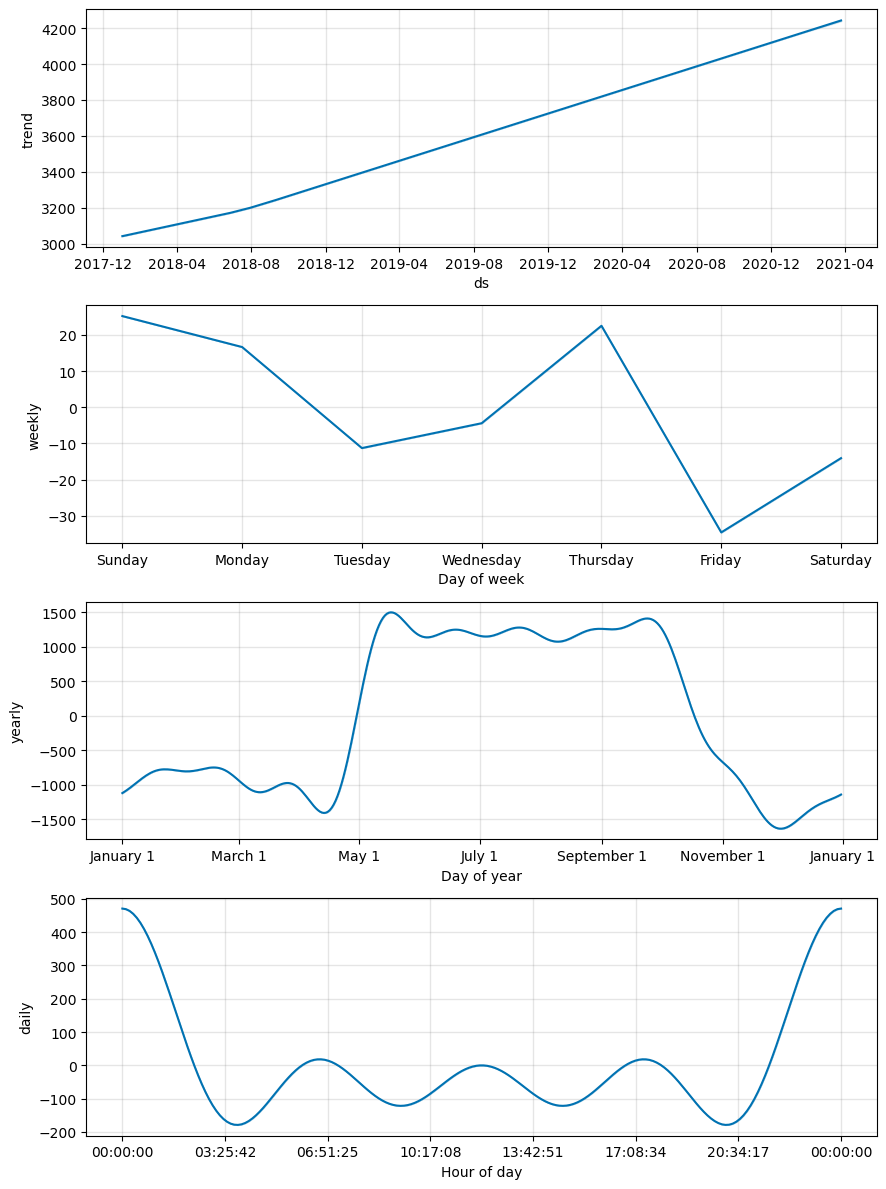

In [21]:
plt2 = m.plot_components(forecast)